<div class="alert alert-block alert-info">
    <h1>Análisis de Series Temporales </h1>
    <h3>Clase 1</h3>
    <h5>Ejercicio 2</h5>
        <p>Docente: Rodrigo Del Rosso<p>
        <p>Asistente: Sebastián Calcagno   <p>

</div>

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf
import statsmodels.api as sm
import matplotlib.pyplot as plt
from matplotlib import rcParams
from cycler import cycler

In [ ]:
from IPython import display
display.set_matplotlib_formats("svg")

/tmp/ipykernel_882/2078667837.py:2: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  display.set_matplotlib_formats("svg")


**RUIDO BLANCO**

In [ ]:
ruido_blanco = np.random.randn(1000)

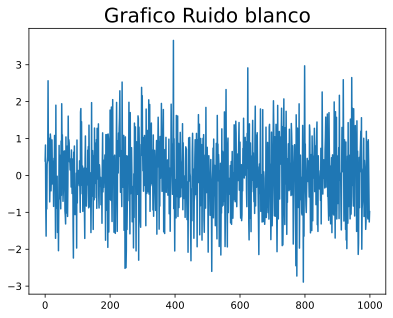

In [ ]:
plt.title("Grafico Ruido blanco", size=20)
plt.plot(np.arange(len(ruido_blanco)),ruido_blanco)

*COMENTARIO NUEVO 1*

Aqui vemos el ploteo de una serie simulada como ruido blanco. La grafica muestra similitudes con respecto al ejercicio 1, cuando se grafico la primera diferencia de la serie original.
¿ se llegan a ver las simulitudes ?

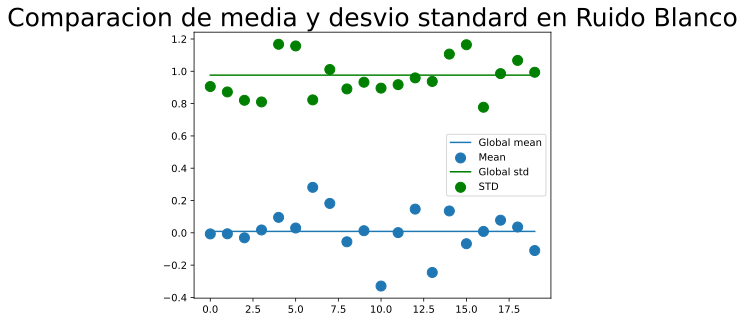

In [ ]:
ruido_blanco_chunks = np.split(ruido_blanco, 20)
means, stds = [], []

for chunk in ruido_blanco_chunks:
    means.append(np.mean(chunk))
    stds.append(np.std(chunk))

plt.title('Comparacion de media y desvio standard en Ruido Blanco', size=25)
plt.plot(np.arange(len(means)), [ruido_blanco.mean()] * len(means), label='Global mean', lw=1.5)
plt.scatter(x=np.arange(len(means)), y=means, label='Mean', s=100)
plt.plot(np.arange(len(stds)), [ruido_blanco.std()] * len(stds), label='Global std', lw=1.5, color='green')
plt.scatter(x=np.arange(len(stds)), y=stds, label='STD', s=100, color='green')
plt.legend();

Este grafico les mostramos una comparacion de  la media y el desvío estándar calculados en distintos segmentos de la serie con sus valores globales. Quiero que vean que las medias de los segmentos oscilan alrededor de cero y que los desvíos estandar se mantienen relativamente constantes. Esto ese lo que es consistente con las propiedades de un proceso de ruido blanco.

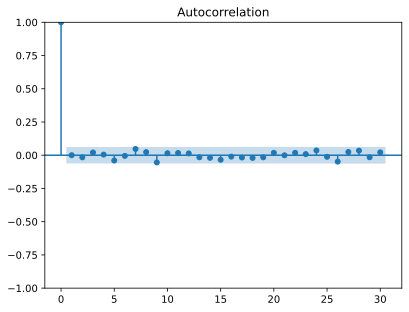

In [ ]:
plot_acf(np.array(ruido_blanco));

el ruido blanco es puro azar sin memoria y es el punto de referencia contra el que se valida cualquier modelo de series temporales.

Aqui vemos la funcion de autocorrelacion de una serie ruido blanco. En base a la teoria, ¿ que pueden comentar sobre este comportamiento ?

Camino aleatorio

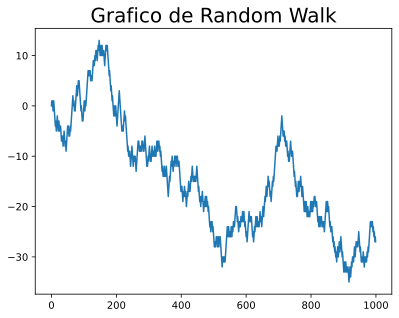

In [ ]:
random_walk = [0]

for i in range(1,1000):
  num= -1 if np.random.random() < 0.5 else 1
  random_walk.append(random_walk[-1] + num)

plt.title('Grafico de Random Walk', size=20)
plt.plot(np.arange(len(random_walk)), random_walk);

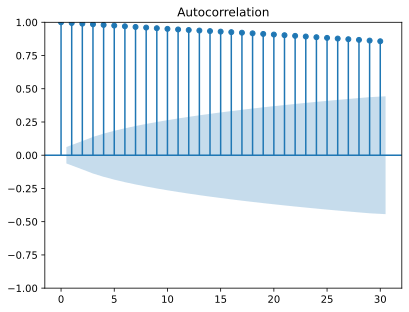

In [ ]:
plot_acf(np.array(random_walk));

Nuevamente, vimos un comportamiento simulado de una serie con comportamiento " random walk". Luego aplicamos la transformacion, y vemos como se modifica la serie a ruido blanco.

In [ ]:
s_random_walk = pd.Series(random_walk)
s_random_walk_diff = s_random_walk.diff().dropna()

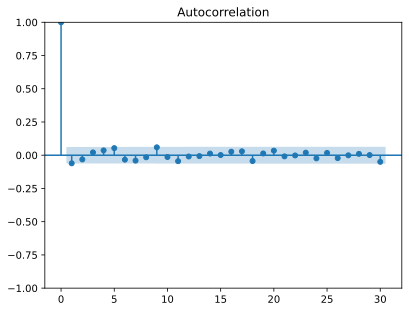

In [ ]:
plot_acf(np.array(s_random_walk_diff));

Ahora vamos a trabajar con un modelo AR2 simulado para ver sus caracteristicas. Aqui es interesante que lo analicen teniendo en cuenta la teoria vista.

In [ ]:
# parámetros del modelo AR(2)
phi_1 = 0.5
phi_2 = 0.2
sigma = 1.0
n = 1000


# Inicializar la serie con ceros
Y = np.zeros(n)

# Generar ruido blanco
np.random.seed(0)
epsilon = np.random.normal(0, sigma, n)

# Simular el proceso AR(2)
for t in range(2, n):
    Y[t] = phi_1 * Y[t-1] + phi_2 * Y[t-2] + epsilon[t]

Es decir, generamos la serie usando la ecuacion del modelo:

Yt = 0,5 Y t-1  +  0,2 Y t-2  +  et


Cada valor de la serie depende de:

50 % del valor anterior
20% del valor de hace dos períodos
un shock aleatorio

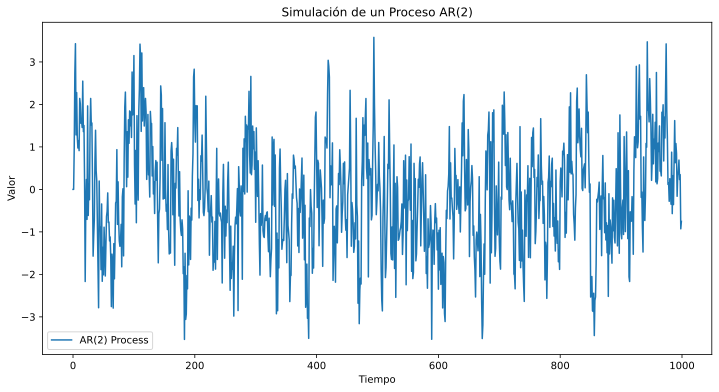

In [ ]:
# Grafica de la serie simulada
plt.figure(figsize=(12, 6))
plt.plot(Y, label='AR(2) Process')
plt.title('Simulación de un Proceso AR(2)')
plt.xlabel('Tiempo')
plt.ylabel('Valor')
plt.legend()
plt.show()

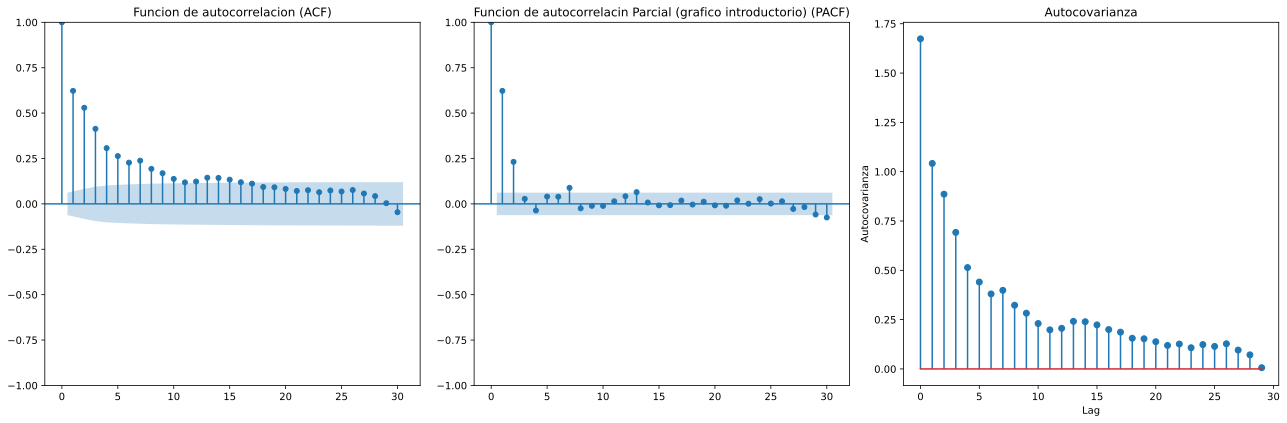

In [ ]:
# Grafica de ACF, PACF y autocovarianza

fig, ax = plt.subplots(1, 3, figsize=(18, 6))


sm.graphics.tsa.plot_acf(Y, lags=30, ax=ax[0])
ax[0].set_title('Funcion de autocorrelacion (ACF)')

sm.graphics.tsa.plot_pacf(Y, lags=30, ax=ax[1])
ax[1].set_title('Funcion de autocorrelacin Parcial (grafico introductorio) (PACF)')

def autocovariance(series, lag):
    series_mean = np.mean(series)
    n = len(series)
    return np.sum((series[:n-lag] - series_mean) * (series[lag:] - series_mean)) / n

lags = np.arange(30)
autocov = [autocovariance(Y, lag) for lag in lags]

ax[2].stem(lags, autocov)
ax[2].set_title('Autocovarianza')
ax[2].set_xlabel('Lag')
ax[2].set_ylabel('Autocovarianza')

plt.tight_layout()
plt.show()


Cual es el analisis que se puede ver aqui ?

Tenemos la funcion de autocorrelacion y la funcion de autocorrelacion parcial y el grafico de autocovarianza ( que tb nos indica dependencia temporales entre observaciones )

La funcion de autocorrelacion nos indica, en lineas generales, si nuestros datos son o no son estracionarios ( obviamente esto es una aproximacion que luego tenemos que verificar con test de hipotesis)

La funcion de autocorrelacion parcial nos indica el orden del modelo "AR" ( es decir aqui, un AR(2) )

Ahora se ve el proceso autoregresivo - Aqui comenzamos a modelar el AR2)

In [ ]:
from statsmodels.tsa.arima_model import ARMA
import statsmodels.api as sm

In [ ]:
modeloAR2 = sm.tsa.arima.ARIMA(Y, order=(2,0,0))
resultadosAR2 = modeloAR2.fit()

In [ ]:
resultadosAR2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -1403.867
Date:                Fri, 06 Mar 2026   AIC                           2815.735
Time:                        14:57:09   BIC                           2835.366
Sample:                             0   HQIC                          2823.196
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1573      0.107     -1.467      0.142      -0.367       0.053
ar.L1          0.4779      0.031     15.434      0.000       0.417       0.539
ar.L2          0.2315      0.031      7.469      0.000       0.171       0.292
sigma2         0.9697      0.044     22.114      0.000       0.884       1.056
===================================================================================
Ljung-Box (L1) (Q):                   0.04   Jarque-Bera (JB):                 0.28
Prob(Q):                              0.85   Prob(JB):                         0.87
Heteroskedasticity (H):               0.99   Skew:                             0.04
Prob(H) (two-sided):                  0.95   Kurtosis:                         2.96
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Estos valores son importantes, ya que nos indican varios puntos relacionados con el modelo en si, los coeficientes del modelo , los residuos del modelo. En principio lo que podemos ver es que la constante del modelo ( el "coef - 0,1573 ) no es significativo y lo podriamos no incluir en el modelo.

Por lo tanto, aqui generamos un ar 2 sin la constante =

In [ ]:
modeloAR2_sinconst = sm.tsa.arima.ARIMA(Y, order=(2, 0, 0), trend='n')
resultadosAR2_sinconstante = modeloAR2_sinconst.fit()


In [ ]:
resultadosAR2_sinconstante.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -1404.932
Date:                Fri, 06 Mar 2026   AIC                           2815.864
Time:                        14:57:18   BIC                           2830.587
Sample:                             0   HQIC                          2821.460
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4804      0.031     15.487      0.000       0.420       0.541
ar.L2          0.2340      0.031      7.576      0.000       0.173       0.295
sigma2         0.9718      0.044     22.087      0.000       0.886       1.058
===================================================================================
Ljung-Box (L1) (Q):                   0.07   Jarque-Bera (JB):                 0.28
Prob(Q):                              0.79   Prob(JB):                         0.87
Heteroskedasticity (H):               1.00   Skew:                             0.04
Prob(H) (two-sided):                  0.96   Kurtosis:                         2.96
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Llegamos a este resumen del modelo AR(2) sin constante, en los resultados tb podemos ver como se comporta los residuos del modelo, que justamente lo ideal es que se comporte como un ruido blanco. Tb vemos la incorrelacion de los residuos del modelo, si tiene un comportamiento normal.
Otro tema que podemos ver son los criterios de informacion del modelo ( que nos sirve para comparar modelos y seleccionar el mejor ) y varios items mas.

Tengan en cuenta que este ejercicio es una introduccion, con valores simulados . Igualmente, podemos sacar muchas conclusiones.

En el transcurso de las clases vamos ir incorporando varias herramientas para poder llegar al modelo que mejor represente nuestros datos.

Espero que este ejercicio tb les haya sido de ayuda para comprender aun mas los aspectos teoricos.